# Batch 2 — F1-Optimized Ensemble + Synthetic Augmentation
### Training: `combined_training.npz` (2200 users) + 300 synthetic anomalies | Test: `second_batch.npz` (860 users)

**Strategy:** All 51 features + 10 synthetic anomaly types + F1-optimized Optuna + Platt calibration

**Models:** XGBoost, CatBoost, LightGBM, Balanced RF → Calibrated Weighted Ensemble

In [88]:
import pandas as pd
import numpy as np
import zipfile, warnings
import xgboost as xgb
import lightgbm as lgb
import optuna
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import entropy
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import IsolationForest
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from imblearn.ensemble import BalancedRandomForestClassifier

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

import importlib, feature_pipeline
importlib.reload(feature_pipeline)

from feature_pipeline import (
    combine_labeled_data, load_data, compute_item_stats,
    build_features, get_feature_columns, get_robust_feature_columns,
    generate_synthetic_anomalies
)

print('Imports OK')

Imports OK


## 1. Load & Combine Training Data + Build Features

In [89]:
# Combine both labeled datasets for maximum training data
combined_path = combine_labeled_data(
    "data/training_batch_with_labels.npz",
    "data/first_batch_with_labels.npz"
)

# Load combined training + test
XX_train, yy, XX_test = load_data(combined_path, test_path="data/second_batch.npz")

print(f"\nTraining interactions: {XX_train.shape[0]:,}")
print(f"Training users: {yy.shape[0]} ({int(yy['label'].sum())} anomalous)")
print(f"Test interactions: {XX_test.shape[0]:,}")
print(f"Test users: {XX_test['user'].nunique()}")

# Augment with synthetic anomalies (10 types x 30 = 300 extra anomalous users)
XX_train, yy = generate_synthetic_anomalies(XX_train, yy, n_per_type=30)

print(f"\nAugmented training interactions: {XX_train.shape[0]:,}")
print(f"Augmented training users: {yy.shape[0]} ({int(yy['label'].sum())} anomalous)")

Combined 2 files → data/combined_training.npz
  2200 users (200 anomalous, 2000 normal), 344839 interactions

Training interactions: 344,839
Training users: 2200 (200 anomalous)
Test interactions: 134,594
Test users: 860
Generated 300 synthetic anomalous users (10 types x 30)
  Training: 2200 -> 2500 users (200 + 300 = 500 anomalous)

Augmented training interactions: 399,167
Augmented training users: 2500 (500 anomalous)


In [90]:
# Compute item stats from training ONLY (leakage-safe)
print("Computing item stats + SVD...")
item_stats = compute_item_stats(XX_train, n_svd_components=20)

# Build features for train and test
print("Building training features...")
train_feats = build_features(XX_train, item_stats).merge(yy, on="user")
print("Building test features...")
test_feats = build_features(XX_test, item_stats)

# Use ALL 51 features (adversarial AUC=0.56 confirmed no shift)
feature_cols = get_feature_columns(train_feats)

X_train = train_feats[feature_cols].values
y_train = train_feats["label"].values
X_test = test_feats[feature_cols].values
test_users = test_feats["user"].values

# Track which users are synthetic for visualization
synth_mask = train_feats["user"].values >= (yy["user"].max() - 300 + 1)

# Scale
scaler = RobustScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print(f"\nFeatures: {len(feature_cols)}")
print(f"Training shape: {X_train_s.shape} ({synth_mask.sum()} synthetic)")
print(f"Test shape: {X_test_s.shape}")
print(f"\nFeature list:")
for i, f in enumerate(feature_cols):
    print(f"  {i+1:2d}. {f}")

Computing item stats + SVD...
Building training features...
Building test features...

Features: 51
Training shape: (2500, 51) (300 synthetic)
Test shape: (860, 51)

Feature list:
   1. rating_mean
   2. rating_std
   3. rating_median
   4. rating_min
   5. rating_max
   6. rating_count
   7. rating_range
   8. rating_skew
   9. rating_kurt
  10. rating_entropy
  11. prop_rating_0
  12. prop_rating_1
  13. prop_rating_2
  14. prop_rating_3
  15. prop_rating_4
  16. prop_rating_5
  17. prop_extreme
  18. prop_zero
  19. prop_five
  20. prop_mid
  21. extreme_mid_ratio
  22. prop_near_extreme
  23. unique_items_rated
  24. item_coverage_ratio
  25. rating_count_vs_median
  26. rating_count_log
  27. repeat_rating_ratio
  28. avg_item_popularity
  29. std_item_popularity
  30. prop_bottom25_pop
  31. prop_top10_pop
  32. pop_vs_global_median
  33. pop_weighted_avg_rating
  34. count_x_pop
  35. mean_deviation
  36. std_deviation
  37. abs_mean_deviation
  38. max_deviation
  39. min_devia

## 1b. Adversarial Validation — Detect Train/Test Distribution Shift

In [91]:
# Adversarial validation: can a classifier distinguish train vs test users?
# High AUC = distribution shift; ~0.5 = distributions match
adv_X = np.vstack([X_train_full, X_test_full])
adv_y = np.array([0]*len(X_train_full) + [1]*len(X_test_full))

adv_model = lgb.LGBMClassifier(n_estimators=100, random_state=42, n_jobs=-1, verbose=-1)
adv_aucs = cross_val_score(adv_model, adv_X, adv_y, cv=5, scoring='roc_auc')
print(f"Adversarial AUC: {adv_aucs.mean():.4f} ± {adv_aucs.std():.4f}")

if adv_aucs.mean() > 0.65:
    print("  → SHIFT DETECTED: some features differ between train/test")
    # Find which features cause the shift
    adv_model.fit(adv_X, adv_y)
    adv_imp = pd.Series(adv_model.feature_importances_, index=feature_cols_full)
    adv_imp = adv_imp.sort_values(ascending=False)
    print("\n  Top 10 train/test discriminating features:")
    for f, v in adv_imp.head(10).items():
        print(f"    {f:30s} importance={v}")
else:
    print("  → No significant shift — problem is anomaly-type difference")

Adversarial AUC: 0.5606 ± 0.0108
  → No significant shift — problem is anomaly-type difference


## 1c. Visualize Batch 2: PCA/t-SNE Clusters + Feature Distributions

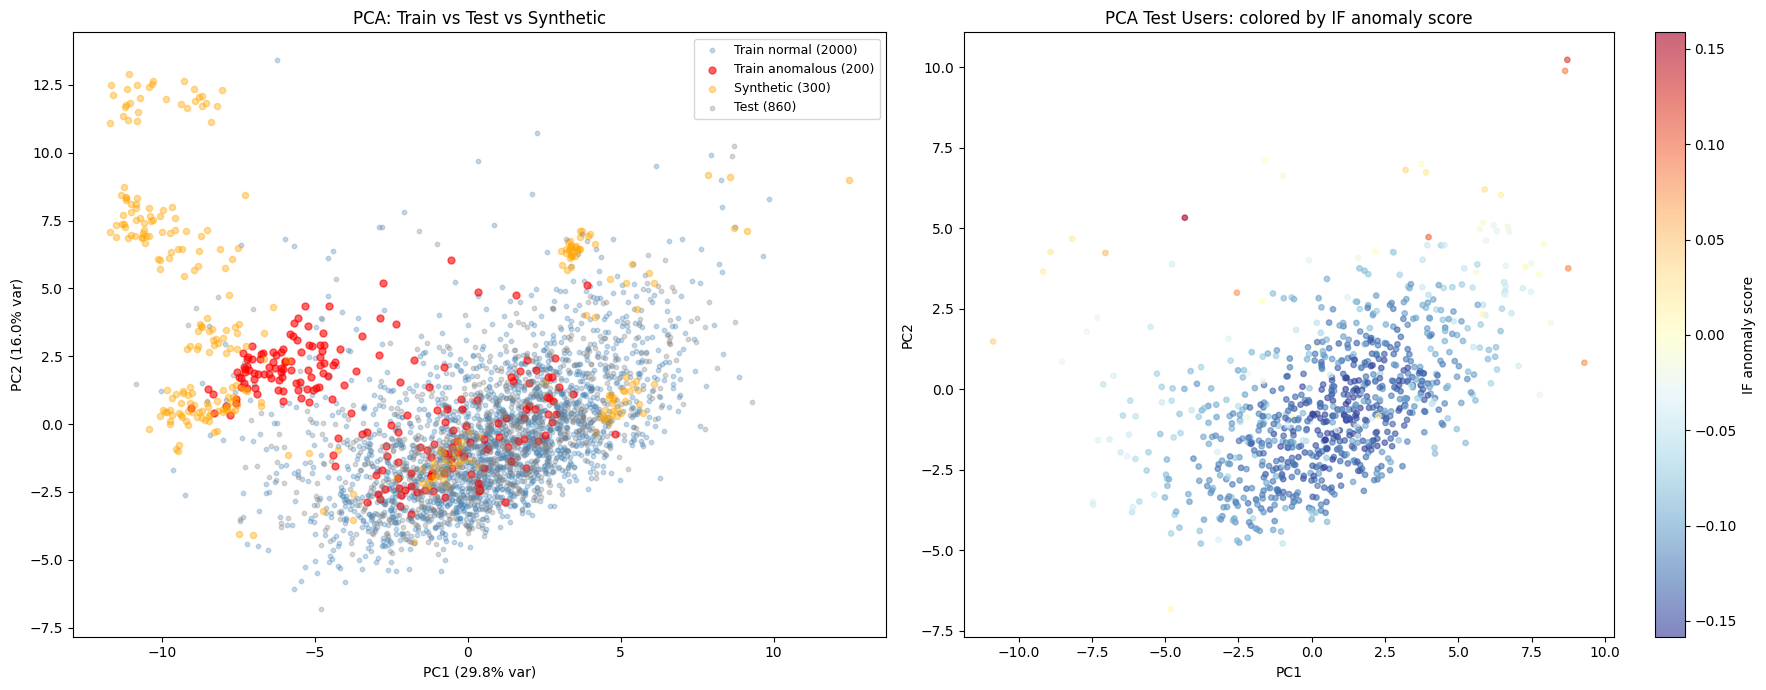


PCA explained variance: 45.9% (2 components)


In [92]:
# --- PCA on combined train+test, colored by source and label ---
# Impute NaN before PCA
imp = SimpleImputer(strategy='median')
X_all = np.vstack([X_train, X_test])
X_all_imp = imp.fit_transform(X_all)

scaler_viz = StandardScaler()
X_all_scaled = scaler_viz.fit_transform(X_all_imp)

pca = PCA(n_components=2, random_state=42)
pca_coords = pca.fit_transform(X_all_scaled)

n_train = len(X_train)
pca_train = pca_coords[:n_train]
pca_test = pca_coords[n_train:]

# Labels for train users
is_normal = (y_train == 0) & ~synth_mask
is_orig_anom = (y_train == 1) & ~synth_mask
is_synth = synth_mask

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot 1: PCA colored by source
ax = axes[0]
ax.scatter(pca_train[is_normal, 0], pca_train[is_normal, 1],
           c='steelblue', alpha=0.3, s=10, label=f'Train normal ({is_normal.sum()})')
ax.scatter(pca_train[is_orig_anom, 0], pca_train[is_orig_anom, 1],
           c='red', alpha=0.6, s=25, label=f'Train anomalous ({is_orig_anom.sum()})')
ax.scatter(pca_train[is_synth, 0], pca_train[is_synth, 1],
           c='orange', alpha=0.4, s=20, label=f'Synthetic ({is_synth.sum()})')
ax.scatter(pca_test[:, 0], pca_test[:, 1],
           c='gray', alpha=0.3, s=10, label=f'Test ({len(pca_test)})')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} var)')
ax.set_title('PCA: Train vs Test vs Synthetic')
ax.legend(fontsize=9)

# Plot 2: PCA test only, colored by IF anomaly score
iso_test_scores = -IsolationForest(n_estimators=300, contamination=0.09,
                                    random_state=42, n_jobs=-1).fit(
    X_all_scaled[:n_train]).decision_function(X_all_scaled[n_train:])

ax = axes[1]
sc = ax.scatter(pca_test[:, 0], pca_test[:, 1],
                c=iso_test_scores, cmap='RdYlBu_r', alpha=0.6, s=15)
plt.colorbar(sc, ax=ax, label='IF anomaly score')
ax.set_xlabel(f'PC1')
ax.set_ylabel(f'PC2')
ax.set_title('PCA Test Users: colored by IF anomaly score')

plt.tight_layout()
plt.show()

print(f"\nPCA explained variance: {pca.explained_variance_ratio_[:2].sum():.1%} (2 components)")

Running t-SNE (may take a minute)...


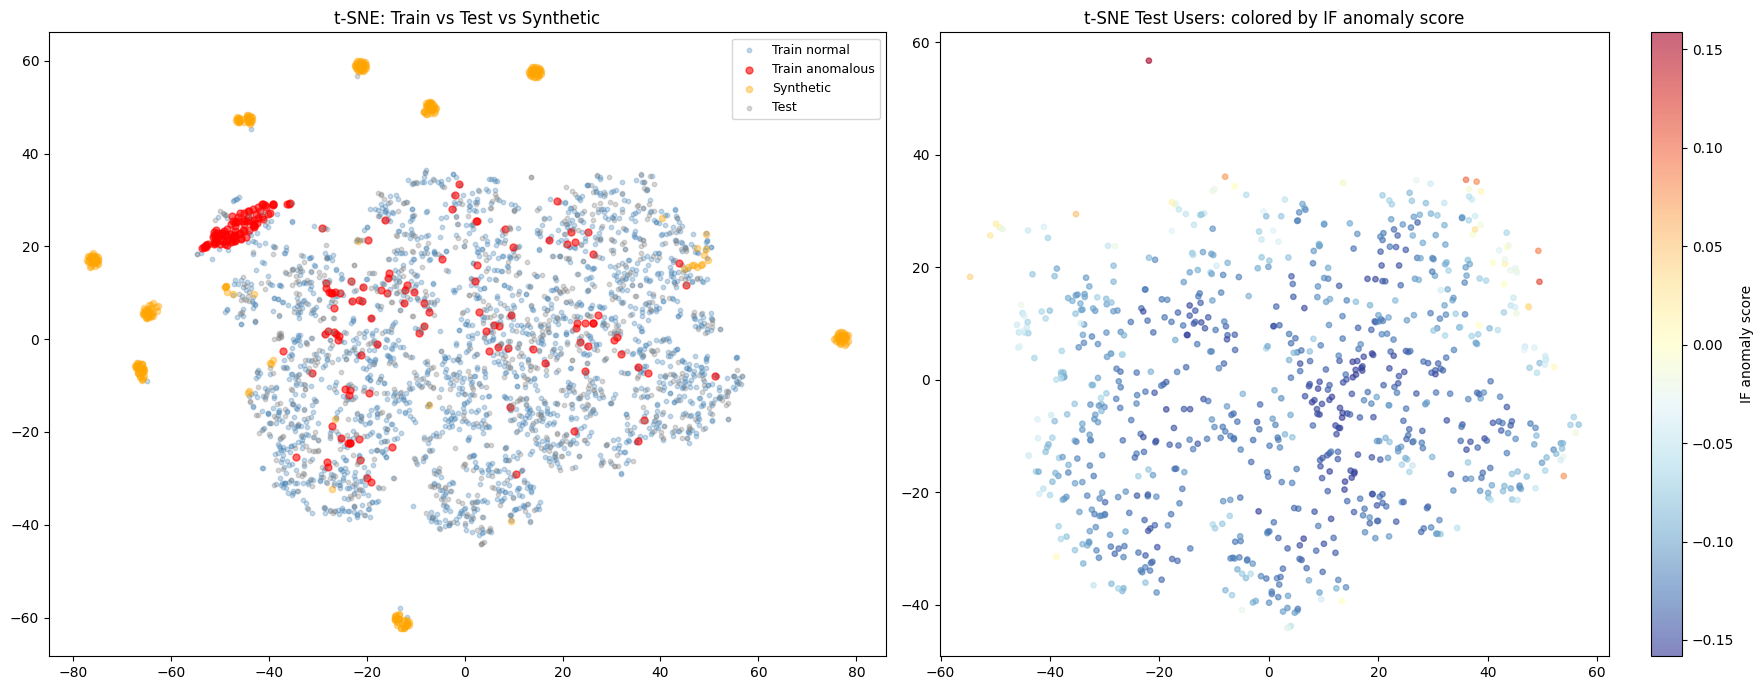

In [93]:
# --- t-SNE on combined train+test ---
print("Running t-SNE (may take a minute)...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
tsne_coords = tsne.fit_transform(X_all_scaled)

tsne_train = tsne_coords[:n_train]
tsne_test = tsne_coords[n_train:]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot 1: t-SNE colored by source
ax = axes[0]
ax.scatter(tsne_train[is_normal, 0], tsne_train[is_normal, 1],
           c='steelblue', alpha=0.3, s=10, label=f'Train normal')
ax.scatter(tsne_train[is_orig_anom, 0], tsne_train[is_orig_anom, 1],
           c='red', alpha=0.6, s=25, label=f'Train anomalous')
ax.scatter(tsne_train[is_synth, 0], tsne_train[is_synth, 1],
           c='orange', alpha=0.4, s=20, label=f'Synthetic')
ax.scatter(tsne_test[:, 0], tsne_test[:, 1],
           c='gray', alpha=0.3, s=10, label=f'Test')
ax.set_title('t-SNE: Train vs Test vs Synthetic')
ax.legend(fontsize=9)

# Plot 2: t-SNE test only, colored by IF score
ax = axes[1]
sc = ax.scatter(tsne_test[:, 0], tsne_test[:, 1],
                c=iso_test_scores, cmap='RdYlBu_r', alpha=0.6, s=15)
plt.colorbar(sc, ax=ax, label='IF anomaly score')
ax.set_title('t-SNE Test Users: colored by IF anomaly score')

plt.tight_layout()
plt.show()

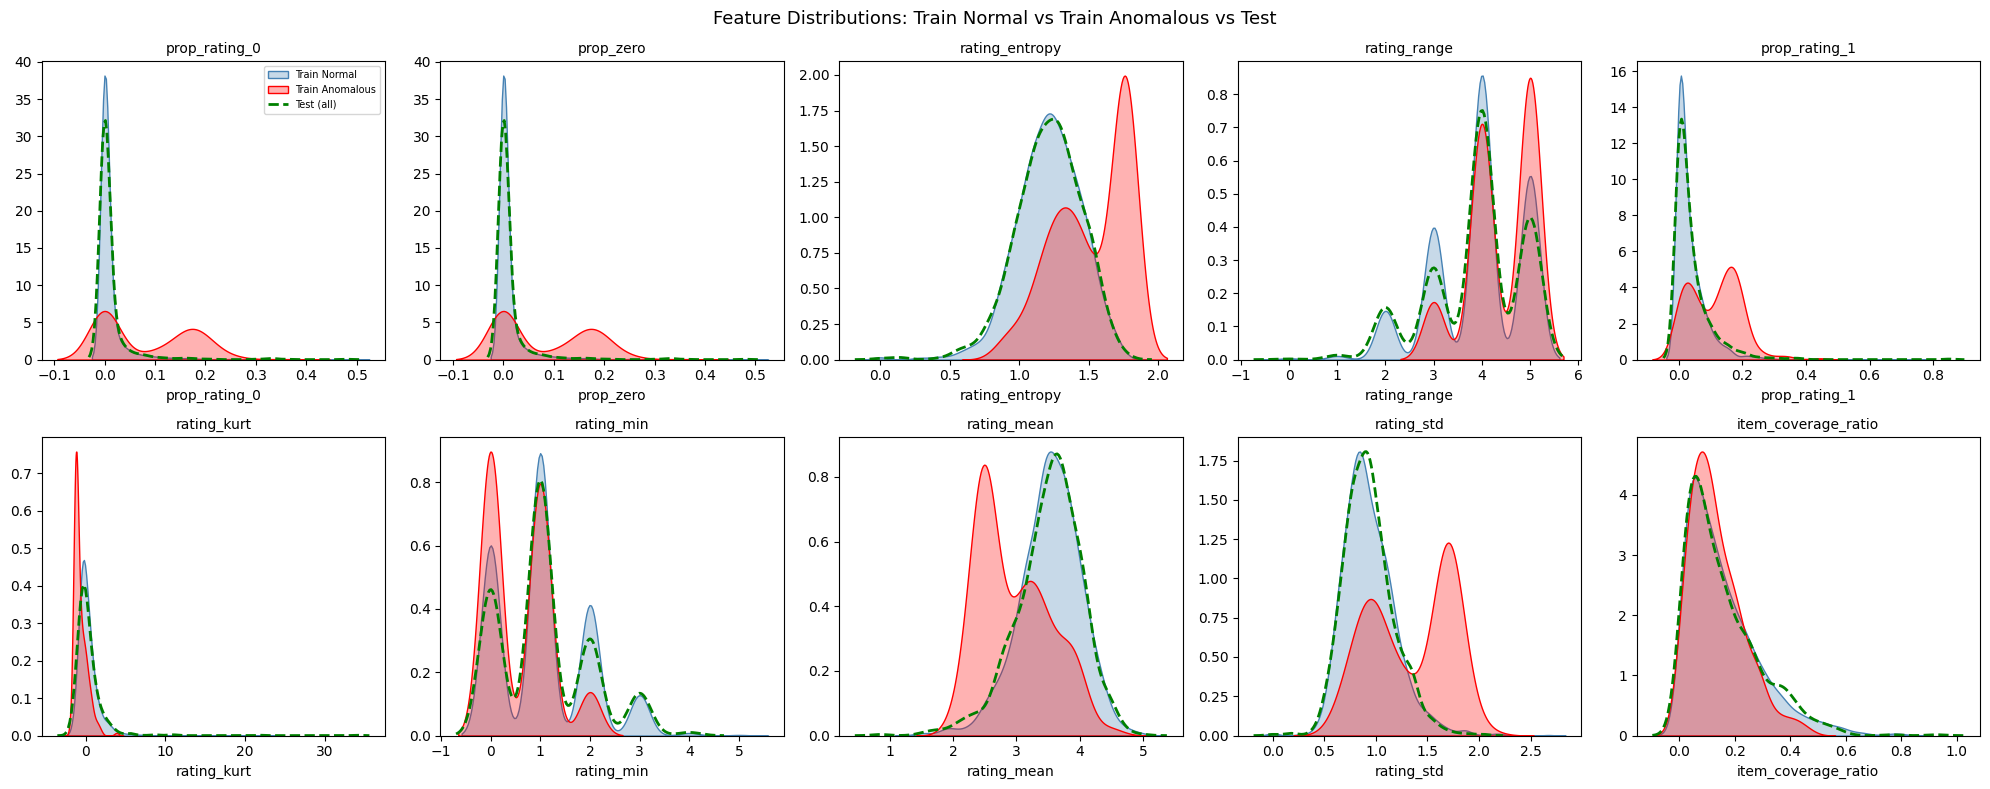

Look for features where Test (green) diverges from Train Normal (blue)
Those features might reveal where test anomalies hide


In [94]:
# --- Feature distributions: Train Normal vs Train Anomalous vs Test ---
top_features = ['prop_rating_0', 'prop_zero', 'rating_entropy', 'rating_range',
                'prop_rating_1', 'rating_kurt', 'rating_min', 'rating_mean',
                'rating_std', 'item_coverage_ratio']

train_normal_feats = train_feats[train_feats["label"] == 0][top_features]
train_anom_feats = train_feats[(train_feats["label"] == 1) & ~synth_mask][top_features]
test_feats_viz = test_feats[top_features]

ncols = 5
nrows = 2
fig, axes = plt.subplots(nrows, ncols, figsize=(20, 8))

for i, feat in enumerate(top_features):
    ax = axes[i // ncols, i % ncols]
    sns.kdeplot(train_normal_feats[feat].dropna(), label='Train Normal',
                fill=True, alpha=0.3, ax=ax, color='steelblue')
    sns.kdeplot(train_anom_feats[feat].dropna(), label='Train Anomalous',
                fill=True, alpha=0.3, ax=ax, color='red')
    sns.kdeplot(test_feats_viz[feat].dropna(), label='Test (all)',
                ax=ax, color='green', linestyle='--', linewidth=2)
    ax.set_title(feat, fontsize=10)
    ax.set_ylabel('')
    if i == 0:
        ax.legend(fontsize=7)
    else:
        ax.get_legend().remove() if ax.get_legend() else None

fig.suptitle('Feature Distributions: Train Normal vs Train Anomalous vs Test', fontsize=13)
plt.tight_layout()
plt.show()

print("Look for features where Test (green) diverges from Train Normal (blue)")
print("Those features might reveal where test anomalies hide")

## 1d. Add Unsupervised Anomaly Scores as Extra Features

In [95]:
# Add Isolation Forest anomaly scores as extra features
# IF captures "structural unusualness" without labels — transfers better across batches
iso = IsolationForest(n_estimators=500, contamination=0.09, random_state=42, n_jobs=-1)
iso.fit(X_train_s)

iso_train = -iso.decision_function(X_train_s).reshape(-1, 1)
iso_test = -iso.decision_function(X_test_s).reshape(-1, 1)

# Append IF scores to feature matrices
X_train_s = np.column_stack([X_train_s, iso_train])
X_test_s = np.column_stack([X_test_s, iso_test])

feature_cols_with_iso = list(feature_cols) + ["iso_forest_score"]

print(f"Added IF anomaly score → final shape: {X_train_s.shape}")
print(f"IF score range (train): [{iso_train.min():.4f}, {iso_train.max():.4f}]")
print(f"IF score range (test):  [{iso_test.min():.4f}, {iso_test.max():.4f}]")

Added IF anomaly score → final shape: (2500, 52)
IF score range (train): [-0.1593, 0.1368]
IF score range (test):  [-0.1571, 0.1562]


## 2. Cross-Validation Setup + Helper Functions

In [96]:
SEED = 42
N_FOLDS = 10
spw = np.sum(y_train == 0) / np.sum(y_train == 1)
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

print(f"Class imbalance ratio: {spw:.2f}")
print(f"Anomalous users: {np.sum(y_train == 1)}, Normal: {np.sum(y_train == 0)}")
print(f"Per fold: ~{np.sum(y_train == 1) // N_FOLDS} anomalous in validation")


def find_best_f1_threshold(scores, y_true):
    """Find threshold that maximizes F1 on given scores."""
    thresholds = np.linspace(0.01, 0.99, 500)
    best_f1, best_t = 0, 0.5
    for t in thresholds:
        preds = (scores >= t).astype(int)
        f1 = f1_score(y_true, preds, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_t = t
    return best_f1, best_t


def evaluate_oof(name, oof_scores, y_true):
    """Evaluate OOF predictions and find best F1 threshold."""
    auc = roc_auc_score(y_true, oof_scores)
    best_f1, best_t = find_best_f1_threshold(oof_scores, y_true)

    preds = (oof_scores >= best_t).astype(int)
    prec = precision_score(y_true, preds, zero_division=0)
    rec = recall_score(y_true, preds, zero_division=0)

    print(f"\n{'='*50}")
    print(f"{name}")
    print(f"{'='*50}")
    print(f"  OOF AUC:     {auc:.4f}")
    print(f"  Best F1:     {best_f1:.4f} (threshold={best_t:.3f})")
    print(f"  Precision:   {prec:.4f}")
    print(f"  Recall:      {rec:.4f}")
    return auc, best_f1, best_t

Class imbalance ratio: 4.00
Anomalous users: 500, Normal: 2000
Per fold: ~50 anomalous in validation


## 3. Model 1 — XGBoost with Optuna

In [97]:
def xgb_objective(trial):
    grow_policy = trial.suggest_categorical('grow_policy', ['depthwise', 'lossguide'])
    params = dict(
        n_estimators      = trial.suggest_int('n_estimators', 100, 1500),
        learning_rate     = trial.suggest_float('learning_rate', 0.005, 0.15, log=True),
        subsample         = trial.suggest_float('subsample', 0.5, 0.9),
        colsample_bytree  = trial.suggest_float('colsample_bytree', 0.3, 0.8),
        colsample_bylevel = trial.suggest_float('colsample_bylevel', 0.4, 0.8),
        min_child_weight  = trial.suggest_int('min_child_weight', 5, 30),
        gamma             = trial.suggest_float('gamma', 0.1, 5.0),
        reg_alpha         = trial.suggest_float('reg_alpha', 0.1, 10.0, log=True),
        reg_lambda        = trial.suggest_float('reg_lambda', 1.0, 20.0, log=True),
        max_delta_step    = trial.suggest_int('max_delta_step', 0, 10),
        scale_pos_weight  = trial.suggest_float('scale_pos_weight', spw * 0.5, spw * 3.0),
        grow_policy       = grow_policy,
    )
    if grow_policy == 'lossguide':
        params['max_leaves'] = trial.suggest_int('max_leaves', 16, 48)
    else:
        params['max_depth'] = trial.suggest_int('max_depth', 3, 6)

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=trial.number)
    f1s = []
    for tr_i, val_i in cv.split(X_train_s, y_train):
        m = xgb.XGBClassifier(
            **params, eval_metric='aucpr', early_stopping_rounds=50,
            random_state=SEED, n_jobs=-1, tree_method='hist'
        )
        m.fit(X_train_s[tr_i], y_train[tr_i],
              eval_set=[(X_train_s[val_i], y_train[val_i])], verbose=False)
        proba = m.predict_proba(X_train_s[val_i])[:, 1]
        best_f1 = max(
            f1_score(y_train[val_i], (proba >= t).astype(int), zero_division=0)
            for t in np.linspace(0.05, 0.95, 100)
        )
        f1s.append(best_f1)
    return np.mean(f1s)

print("Running XGBoost Optuna search (150 trials, F1-optimized)...")
xgb_study = optuna.create_study(direction='maximize')
xgb_study.optimize(xgb_objective, n_trials=150, show_progress_bar=True)

xgb_best = xgb_study.best_params
print(f'\nBest XGBoost CV F1: {xgb_study.best_value:.4f}')
print('Best params:', xgb_best)

Running XGBoost Optuna search (150 trials, F1-optimized)...


Best trial: 95. Best value: 0.854: 100%|██████████| 150/150 [03:04<00:00,  1.23s/it]  


Best XGBoost CV F1: 0.8540
Best params: {'grow_policy': 'lossguide', 'n_estimators': 408, 'learning_rate': 0.10027599306542447, 'subsample': 0.824382855786545, 'colsample_bytree': 0.6743762458484253, 'colsample_bylevel': 0.7179460091209088, 'min_child_weight': 6, 'gamma': 0.9257184363776852, 'reg_alpha': 0.20216188371586968, 'reg_lambda': 1.0868736834743142, 'max_delta_step': 1, 'scale_pos_weight': 7.110079641674014, 'max_leaves': 47}


In [98]:
# XGBoost OOF predictions (10-fold)
oof_xgb = np.zeros(len(y_train))
test_preds_xgb = np.zeros(len(X_test_s))
xgb_models = []

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train_s, y_train)):
    m = xgb.XGBClassifier(
        **xgb_best, eval_metric='aucpr', early_stopping_rounds=50,
        random_state=SEED, n_jobs=-1, tree_method='hist'
    )
    m.fit(X_train_s[tr_idx], y_train[tr_idx],
          eval_set=[(X_train_s[val_idx], y_train[val_idx])], verbose=False)
    oof_xgb[val_idx] = m.predict_proba(X_train_s[val_idx])[:, 1]
    test_preds_xgb += m.predict_proba(X_test_s)[:, 1] / N_FOLDS
    xgb_models.append(m)
    print(f"  Fold {fold+1:2d}: AUC={roc_auc_score(y_train[val_idx], oof_xgb[val_idx]):.4f}")

xgb_auc, xgb_f1, xgb_thresh = evaluate_oof("XGBoost", oof_xgb, y_train)

  Fold  1: AUC=0.9312
  Fold  2: AUC=0.9550
  Fold  3: AUC=0.9686
  Fold  4: AUC=0.9635
  Fold  5: AUC=0.9638
  Fold  6: AUC=0.9536
  Fold  7: AUC=0.9720
  Fold  8: AUC=0.9622
  Fold  9: AUC=0.9560
  Fold 10: AUC=0.9674

XGBoost
  OOF AUC:     0.9527
  Best F1:     0.8399 (threshold=0.829)
  Precision:   0.9542
  Recall:      0.7500


## 4. Model 2 — CatBoost with Optuna

In [99]:
try:
    from catboost import CatBoostClassifier
    HAS_CATBOOST = True
except ImportError:
    HAS_CATBOOST = False
    print("CatBoost not installed. Run: pip install catboost")

if HAS_CATBOOST:
    def cat_objective(trial):
        params = dict(
            iterations     = trial.suggest_int('iterations', 200, 1500),
            learning_rate  = trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
            depth          = trial.suggest_int('depth', 3, 6),
            l2_leaf_reg    = trial.suggest_float('l2_leaf_reg', 3.0, 30.0),
            bagging_temperature = trial.suggest_float('bagging_temperature', 0, 3.0),
            random_strength     = trial.suggest_float('random_strength', 0.5, 5.0),
            border_count        = trial.suggest_int('border_count', 32, 255),
            auto_class_weights  = 'Balanced',
            eval_metric         = 'AUC',
            random_seed         = SEED,
            verbose             = 0,
        )
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=trial.number)
        f1s = []
        for tr_i, val_i in cv.split(X_train_s, y_train):
            m = CatBoostClassifier(**params)
            m.fit(X_train_s[tr_i], y_train[tr_i],
                  eval_set=(X_train_s[val_i], y_train[val_i]),
                  early_stopping_rounds=50, verbose=0)
            proba = m.predict_proba(X_train_s[val_i])[:, 1]
            best_f1 = max(
                f1_score(y_train[val_i], (proba >= t).astype(int), zero_division=0)
                for t in np.linspace(0.05, 0.95, 100)
            )
            f1s.append(best_f1)
        return np.mean(f1s)

    print("Running CatBoost Optuna search (100 trials, F1-optimized)...")
    cat_study = optuna.create_study(direction='maximize')
    cat_study.optimize(cat_objective, n_trials=100, show_progress_bar=True)
    cat_best = cat_study.best_params
    print(f'\nBest CatBoost CV F1: {cat_study.best_value:.4f}')
    print('Best params:', cat_best)

Running CatBoost Optuna search (100 trials, F1-optimized)...


Best trial: 13. Best value: 0.85354: 100%|██████████| 100/100 [05:16<00:00,  3.17s/it]


Best CatBoost CV F1: 0.8535
Best params: {'iterations': 1163, 'learning_rate': 0.05766522009741981, 'depth': 5, 'l2_leaf_reg': 10.33906564847197, 'bagging_temperature': 2.968583251300579, 'random_strength': 3.9371043447695326, 'border_count': 251}


In [100]:
# CatBoost OOF predictions (10-fold)
if HAS_CATBOOST:
    oof_cat = np.zeros(len(y_train))
    test_preds_cat = np.zeros(len(X_test_s))

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train_s, y_train)):
        m = CatBoostClassifier(
            **cat_best,
            auto_class_weights='Balanced',
            eval_metric='AUC',
            random_seed=SEED,
            verbose=0,
        )
        m.fit(X_train_s[tr_idx], y_train[tr_idx],
              eval_set=(X_train_s[val_idx], y_train[val_idx]),
              early_stopping_rounds=50, verbose=0)
        oof_cat[val_idx] = m.predict_proba(X_train_s[val_idx])[:, 1]
        test_preds_cat += m.predict_proba(X_test_s)[:, 1] / N_FOLDS
        print(f"  Fold {fold+1:2d}: AUC={roc_auc_score(y_train[val_idx], oof_cat[val_idx]):.4f}")

    cat_auc, cat_f1, cat_thresh = evaluate_oof("CatBoost", oof_cat, y_train)
else:
    oof_cat = oof_xgb.copy()
    test_preds_cat = test_preds_xgb.copy()
    cat_f1 = 0
    print("Skipping CatBoost (not installed)")

  Fold  1: AUC=0.9309
  Fold  2: AUC=0.9584
  Fold  3: AUC=0.9695
  Fold  4: AUC=0.9466
  Fold  5: AUC=0.9454
  Fold  6: AUC=0.9514
  Fold  7: AUC=0.9713
  Fold  8: AUC=0.9669
  Fold  9: AUC=0.9481
  Fold 10: AUC=0.9632

CatBoost
  OOF AUC:     0.9442
  Best F1:     0.8117 (threshold=0.556)
  Precision:   0.8460
  Recall:      0.7800


## 5. Model 3 — LightGBM with Optuna

In [101]:
def lgb_objective(trial):
    params = dict(
        n_estimators      = trial.suggest_int('n_estimators', 100, 1500),
        learning_rate     = trial.suggest_float('learning_rate', 0.005, 0.15, log=True),
        num_leaves        = trial.suggest_int('num_leaves', 8, 48),
        subsample         = trial.suggest_float('subsample', 0.5, 0.9),
        colsample_bytree  = trial.suggest_float('colsample_bytree', 0.3, 0.8),
        min_child_samples = trial.suggest_int('min_child_samples', 20, 100),
        reg_alpha         = trial.suggest_float('reg_alpha', 0.1, 10.0, log=True),
        reg_lambda        = trial.suggest_float('reg_lambda', 1.0, 20.0, log=True),
        min_gain_to_split = trial.suggest_float('min_gain_to_split', 0.01, 1.0),
        scale_pos_weight  = trial.suggest_float('scale_pos_weight', spw * 0.5, spw * 3.0),
        random_state      = SEED,
        n_jobs            = -1,
        verbose           = -1,
    )
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=trial.number)
    f1s = []
    for tr_i, val_i in cv.split(X_train_s, y_train):
        m = lgb.LGBMClassifier(**params)
        m.fit(X_train_s[tr_i], y_train[tr_i],
              eval_set=[(X_train_s[val_i], y_train[val_i])],
              callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)])
        proba = m.predict_proba(X_train_s[val_i])[:, 1]
        best_f1 = max(
            f1_score(y_train[val_i], (proba >= t).astype(int), zero_division=0)
            for t in np.linspace(0.05, 0.95, 100)
        )
        f1s.append(best_f1)
    return np.mean(f1s)

print("Running LightGBM Optuna search (150 trials, F1-optimized)...")
lgb_study = optuna.create_study(direction='maximize')
lgb_study.optimize(lgb_objective, n_trials=150, show_progress_bar=True)

lgb_best = lgb_study.best_params
print(f'\nBest LightGBM CV F1: {lgb_study.best_value:.4f}')
print('Best params:', lgb_best)

Running LightGBM Optuna search (150 trials, F1-optimized)...


Best trial: 55. Best value: 0.858849: 100%|██████████| 150/150 [03:38<00:00,  1.46s/it]


Best LightGBM CV F1: 0.8588
Best params: {'n_estimators': 466, 'learning_rate': 0.03213707968577014, 'num_leaves': 37, 'subsample': 0.6465636673606359, 'colsample_bytree': 0.7373961618364089, 'min_child_samples': 65, 'reg_alpha': 0.41493076744962193, 'reg_lambda': 1.6579850810451173, 'min_gain_to_split': 0.39531534192021833, 'scale_pos_weight': 6.701450475732782}


In [102]:
# LightGBM OOF predictions (10-fold)
oof_lgb = np.zeros(len(y_train))
test_preds_lgb = np.zeros(len(X_test_s))

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train_s, y_train)):
    m = lgb.LGBMClassifier(**lgb_best, random_state=SEED, n_jobs=-1, verbose=-1)
    m.fit(X_train_s[tr_idx], y_train[tr_idx],
          eval_set=[(X_train_s[val_idx], y_train[val_idx])],
          callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)])
    oof_lgb[val_idx] = m.predict_proba(X_train_s[val_idx])[:, 1]
    test_preds_lgb += m.predict_proba(X_test_s)[:, 1] / N_FOLDS
    print(f"  Fold {fold+1:2d}: AUC={roc_auc_score(y_train[val_idx], oof_lgb[val_idx]):.4f}")

lgb_auc, lgb_f1, lgb_thresh = evaluate_oof("LightGBM", oof_lgb, y_train)

  Fold  1: AUC=0.9303
  Fold  2: AUC=0.9540
  Fold  3: AUC=0.9735
  Fold  4: AUC=0.9584
  Fold  5: AUC=0.9590
  Fold  6: AUC=0.9439
  Fold  7: AUC=0.9692
  Fold  8: AUC=0.9582
  Fold  9: AUC=0.9575
  Fold 10: AUC=0.9681

LightGBM
  OOF AUC:     0.9572
  Best F1:     0.8446 (threshold=0.752)
  Precision:   0.9324
  Recall:      0.7720


## 6. Model 4 — Balanced Random Forest

In [103]:
# Balanced Random Forest — undersamples majority per bootstrap (10-fold)
oof_brf = np.zeros(len(y_train))
test_preds_brf = np.zeros(len(X_test_s))

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train_s, y_train)):
    m = BalancedRandomForestClassifier(
        n_estimators=500, max_depth=10, min_samples_leaf=5,
        random_state=SEED, n_jobs=-1
    )
    m.fit(X_train_s[tr_idx], y_train[tr_idx])
    oof_brf[val_idx] = m.predict_proba(X_train_s[val_idx])[:, 1]
    test_preds_brf += m.predict_proba(X_test_s)[:, 1] / N_FOLDS
    print(f"  Fold {fold+1:2d}: AUC={roc_auc_score(y_train[val_idx], oof_brf[val_idx]):.4f}")

brf_auc, brf_f1, brf_thresh = evaluate_oof("Balanced RF", oof_brf, y_train)

  Fold  1: AUC=0.9363
  Fold  2: AUC=0.9484
  Fold  3: AUC=0.9763
  Fold  4: AUC=0.9486
  Fold  5: AUC=0.9505
  Fold  6: AUC=0.9426
  Fold  7: AUC=0.9663
  Fold  8: AUC=0.9565
  Fold  9: AUC=0.9459
  Fold 10: AUC=0.9700

Balanced RF
  OOF AUC:     0.9537
  Best F1:     0.8335 (threshold=0.686)
  Precision:   0.9443
  Recall:      0.7460


## 7. Model Comparison Summary

In [104]:
# Summary of all 4 models
results = pd.DataFrame({
    'Model': ['XGBoost', 'CatBoost' if HAS_CATBOOST else 'CatBoost (skipped)',
              'LightGBM', 'Balanced RF'],
    'OOF AUC': [roc_auc_score(y_train, oof_xgb),
                roc_auc_score(y_train, oof_cat),
                roc_auc_score(y_train, oof_lgb),
                roc_auc_score(y_train, oof_brf)],
    'OOF F1': [xgb_f1, cat_f1, lgb_f1, brf_f1],
})
results = results.sort_values('OOF F1', ascending=False).reset_index(drop=True)
print(results.to_string(index=False))

      Model  OOF AUC   OOF F1
   LightGBM 0.957235 0.844639
    XGBoost 0.952725 0.839866
Balanced RF 0.953730 0.833520
   CatBoost 0.944191 0.811655


## 8. Platt Calibration + Calibrated Weighted Ensemble

In [105]:
# Platt calibration: fit LogisticRegression on OOF scores → calibrated probabilities
# This ensures scores are well-calibrated so thresholds transfer to test data

def platt_calibrate(oof_scores, test_scores, y_true):
    """Platt scaling: calibrate OOF scores and apply to test."""
    cal = LogisticRegression(C=1e5, max_iter=1000, random_state=SEED)
    cal.fit(oof_scores.reshape(-1, 1), y_true)
    oof_cal = cal.predict_proba(oof_scores.reshape(-1, 1))[:, 1]
    test_cal = cal.predict_proba(test_scores.reshape(-1, 1))[:, 1]
    return oof_cal, test_cal

# Calibrate each model
oof_xgb_cal, test_xgb_cal = platt_calibrate(oof_xgb, test_preds_xgb, y_train)
oof_cat_cal, test_cat_cal = platt_calibrate(oof_cat, test_preds_cat, y_train)
oof_lgb_cal, test_lgb_cal = platt_calibrate(oof_lgb, test_preds_lgb, y_train)
oof_brf_cal, test_brf_cal = platt_calibrate(oof_brf, test_preds_brf, y_train)

print("Calibrated OOF score stats:")
for name, oof_cal in [("XGBoost", oof_xgb_cal), ("CatBoost", oof_cat_cal),
                       ("LightGBM", oof_lgb_cal), ("Balanced RF", oof_brf_cal)]:
    print(f"  {name:12s}: mean={oof_cal.mean():.4f}, >0.5: {(oof_cal > 0.5).sum()}/{len(oof_cal)}")

# F1-weighted ensemble of calibrated probabilities
model_f1s = np.array([xgb_f1, cat_f1, lgb_f1, brf_f1])
weights = model_f1s / model_f1s.sum()

oof_ensemble = (weights[0] * oof_xgb_cal + weights[1] * oof_cat_cal +
                weights[2] * oof_lgb_cal + weights[3] * oof_brf_cal)
test_ensemble = (weights[0] * test_xgb_cal + weights[1] * test_cat_cal +
                 weights[2] * test_lgb_cal + weights[3] * test_brf_cal)

print(f"\nEnsemble weights: XGB={weights[0]:.3f}, CAT={weights[1]:.3f}, "
      f"LGB={weights[2]:.3f}, BRF={weights[3]:.3f}")

ens_auc, ens_f1, ens_thresh = evaluate_oof("Calibrated Weighted Ensemble", oof_ensemble, y_train)

# Stacking meta-learner on calibrated OOF
oof_stack = np.column_stack([oof_xgb_cal, oof_cat_cal, oof_lgb_cal, oof_brf_cal])
test_stack = np.column_stack([test_xgb_cal, test_cat_cal, test_lgb_cal, test_brf_cal])

oof_meta = np.zeros(len(y_train))
test_meta = np.zeros(len(X_test_s))

for fold, (tr_idx, val_idx) in enumerate(skf.split(oof_stack, y_train)):
    meta = LogisticRegression(C=1.0, max_iter=1000, random_state=SEED)
    meta.fit(oof_stack[tr_idx], y_train[tr_idx])
    oof_meta[val_idx] = meta.predict_proba(oof_stack[val_idx])[:, 1]
    test_meta += meta.predict_proba(test_stack)[:, 1] / N_FOLDS

meta_auc, meta_f1, meta_thresh = evaluate_oof("Stacking (calibrated)", oof_meta, y_train)

Calibrated OOF score stats:
  XGBoost     : mean=0.2001, >0.5: 463/2500
  CatBoost    : mean=0.2000, >0.5: 432/2500
  LightGBM    : mean=0.2000, >0.5: 446/2500
  Balanced RF : mean=0.2000, >0.5: 431/2500

Ensemble weights: XGB=0.252, CAT=0.244, LGB=0.254, BRF=0.250

Calibrated Weighted Ensemble
  OOF AUC:     0.9564
  Best F1:     0.8440 (threshold=0.607)
  Precision:   0.9366
  Recall:      0.7680

Stacking (calibrated)
  OOF AUC:     0.9547
  Best F1:     0.8445 (threshold=0.711)
  Precision:   0.9410
  Recall:      0.7660


In [106]:
# Pick the best approach based on OOF F1 (not AUC)
best_approaches = {
    'XGBoost (calibrated)':       (test_xgb_cal, xgb_f1),
    'CatBoost (calibrated)':      (test_cat_cal, cat_f1),
    'LightGBM (calibrated)':      (test_lgb_cal, lgb_f1),
    'Balanced RF (calibrated)':   (test_brf_cal, brf_f1),
    'Weighted Ensemble':          (test_ensemble, ens_f1),
    'Stacking (calibrated)':      (test_meta, meta_f1),
}

print("\nAll approaches ranked by OOF F1:")
for name, (_, f1) in sorted(best_approaches.items(), key=lambda x: -x[1][1] if isinstance(x[1], tuple) else -x[1]):
    print(f"  {name:30s}: F1={f1:.4f}" if not isinstance(f1, tuple) else f"  {name:30s}: F1={f1:.4f}")

best_name = max(best_approaches, key=lambda k: best_approaches[k][1])
best_test_preds = best_approaches[best_name][0]
best_f1 = best_approaches[best_name][1]
print(f"\n>>> Best approach: {best_name} (OOF F1 = {best_f1:.4f})")

# Sanity check: how many users flagged?
for name, (preds, _) in best_approaches.items():
    n_flagged = (preds > 0.5).sum()
    pct = n_flagged / len(preds) * 100
    print(f"  {name:30s}: {n_flagged}/{len(preds)} flagged ({pct:.1f}%)")
print(f"\n  Expected anomaly rate: ~9% ({int(len(test_preds_xgb)*0.09)} users)")


All approaches ranked by OOF F1:
  LightGBM (calibrated)         : F1=0.8446
  Stacking (calibrated)         : F1=0.8445
  Weighted Ensemble             : F1=0.8440
  XGBoost (calibrated)          : F1=0.8399
  Balanced RF (calibrated)      : F1=0.8335
  CatBoost (calibrated)         : F1=0.8117

>>> Best approach: LightGBM (calibrated) (OOF F1 = 0.8446)
  XGBoost (calibrated)          : 31/860 flagged (3.6%)
  CatBoost (calibrated)         : 22/860 flagged (2.6%)
  LightGBM (calibrated)         : 26/860 flagged (3.0%)
  Balanced RF (calibrated)      : 21/860 flagged (2.4%)
  Weighted Ensemble             : 21/860 flagged (2.4%)
  Stacking (calibrated)         : 23/860 flagged (2.7%)

  Expected anomaly rate: ~9% (77 users)


## 9. Feature Importance (XGBoost)

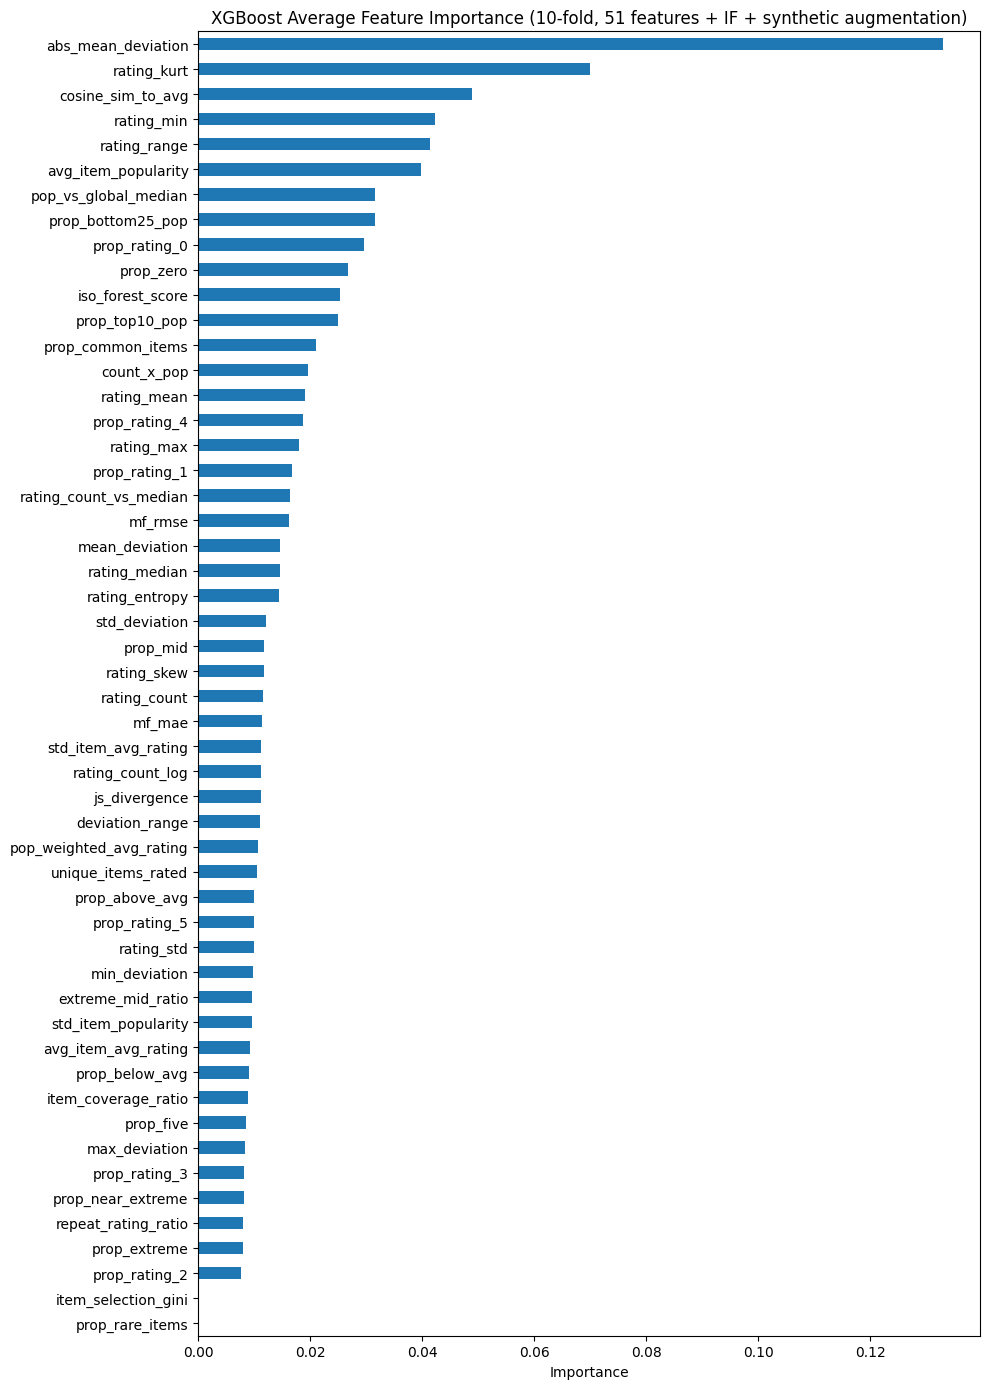


Top 15 features:
abs_mean_deviation      0.132911
rating_kurt             0.069994
cosine_sim_to_avg       0.048909
rating_min              0.042293
rating_range            0.041297
avg_item_popularity     0.039733
pop_vs_global_median    0.031517
prop_bottom25_pop       0.031453
prop_rating_0           0.029511
prop_zero               0.026711
iso_forest_score        0.025261
prop_top10_pop          0.024872
prop_common_items       0.020935
count_x_pop             0.019601
rating_mean             0.018988


In [107]:
# Average feature importance across XGBoost fold models
avg_imp = np.mean([m.feature_importances_ for m in xgb_models], axis=0)
feat_names = list(feature_cols) + ["iso_forest_score"]
feat_imp = pd.Series(avg_imp, index=feat_names).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 14))
feat_imp.plot.barh(ax=ax)
ax.invert_yaxis()
ax.set_title('XGBoost Average Feature Importance (10-fold, 51 features + IF + synthetic augmentation)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

print("\nTop 15 features:")
print(feat_imp.head(15).to_string())

## 10. Generate Submission for second_batch

In [108]:
# Sort predictions by user ID (Codabench expects this order)
test_order = test_feats.sort_values('user').reset_index(drop=True)
sort_idx = test_feats['user'].argsort().values

# Use best approach's predictions, reordered by user ID
y_score = best_test_preds[sort_idx]

# Normalise to [0, 1]
y_score_norm = (y_score - y_score.min()) / (y_score.max() - y_score.min() + 1e-9)

# Save submission
np.savez('submission.npz', predictions=y_score_norm)
with zipfile.ZipFile('submission.zip', 'w', zipfile.ZIP_DEFLATED) as zf:
    zf.write('submission.npz', arcname='submission.npz')

print(f"Submission method: {best_name}")
print(f"Users predicted:   {len(y_score_norm)}")
print(f"First 5 user IDs:  {test_order['user'].values[:5]}")
print(f"Score range:       [{y_score_norm.min():.4f}, {y_score_norm.max():.4f}]")
print(f"Score mean:        {y_score_norm.mean():.4f}")
print(f"Flagged (>0.5):    {(y_score_norm > 0.5).sum()}/{len(y_score_norm)} "
      f"({(y_score_norm > 0.5).sum()/len(y_score_norm)*100:.1f}%)")
print(f"\nsubmission.zip ready for Codabench")

Submission method: LightGBM (calibrated)
Users predicted:   860
First 5 user IDs:  [4100 4101 4102 4103 4104]
Score range:       [0.0000, 1.0000]
Score mean:        0.0503
Flagged (>0.5):    27/860 (3.1%)

submission.zip ready for Codabench


In [109]:
# Save alternative submissions (3 per week strategy)
import os
os.makedirs('submission_files', exist_ok=True)

alternatives = {
    'xgboost_cal':    test_xgb_cal,
    'catboost_cal':   test_cat_cal,
    'lightgbm_cal':   test_lgb_cal,
    'brf_cal':        test_brf_cal,
    'weighted_ens':   test_ensemble,
    'stacking_cal':   test_meta,
}

for name, preds in alternatives.items():
    p = preds[sort_idx]
    p_norm = (p - p.min()) / (p.max() - p.min() + 1e-9)
    np.savez(f'submission_files/{name}.npz', predictions=p_norm)
    with zipfile.ZipFile(f'submission_files/{name}.zip', 'w', zipfile.ZIP_DEFLATED) as zf:
        zf.write(f'submission_files/{name}.npz', arcname='submission.npz')

print("Alternative submissions saved in submission_files/:")
for name, preds in alternatives.items():
    p = preds[sort_idx]
    p_norm = (p - p.min()) / (p.max() - p.min() + 1e-9)
    n_flagged = (p_norm > 0.5).sum()
    print(f"  {name}.zip  (flagged: {n_flagged}/{len(p_norm)}, {n_flagged/len(p_norm)*100:.1f}%)")

print(f"\nRecommended 3 submissions:")
print(f"  1. Best single model (calibrated)")
print(f"  2. weighted_ens.zip (calibrated weighted ensemble)")
print(f"  3. stacking_cal.zip (stacking on calibrated OOF)")

Alternative submissions saved in submission_files/:
  xgboost_cal.zip  (flagged: 33/860, 3.8%)
  catboost_cal.zip  (flagged: 23/860, 2.7%)
  lightgbm_cal.zip  (flagged: 27/860, 3.1%)
  brf_cal.zip  (flagged: 22/860, 2.6%)
  weighted_ens.zip  (flagged: 24/860, 2.8%)
  stacking_cal.zip  (flagged: 23/860, 2.7%)

Recommended 3 submissions:
  1. Best single model (calibrated)
  2. weighted_ens.zip (calibrated weighted ensemble)
  3. stacking_cal.zip (stacking on calibrated OOF)
